# โครงงานปลายภาค: CASMI26 PubChem Popularity Prior
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | ภาคการศึกษา 1/2568

**สมาชิก:** นายธีรภัทร พิกุลศรี (รหัสนักศึกษา 68114540308)

**ชุดข้อมูล:** CASMI26 PubChem Popularity Prior จาก Kaggle

**ปัญหาที่ศึกษา:** ศึกษาความสัมพันธ์ระหว่างข้อมูลการอ้างอิงสารเคมีกับคะแนนความนิยม และสร้างแบบจำลอง regression เพื่อทำนายคะแนนดังกล่าว

| CLO | เนื้อหาที่ครอบคลุม | สถานะ |
|---|---|---|
| CLO1 | PCA และ covariance/eigendecomposition | เสร็จสิ้น |
| CLO2 | EDA, correlation และ bias-variance | เสร็จสิ้น |
| CLO3 | Linear Regression และ Ridge | เสร็จสิ้น |
| CLO4 | 5-Fold Cross-Validation | เสร็จสิ้น |


In [1]:
# Import libraries
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
print("เตรียมไลบรารีเรียบร้อย")

เตรียมไลบรารีเรียบร้อย


---
## Part 1: ภาพรวมชุดข้อมูลและการวิเคราะห์ข้อมูลเบื้องต้น (EDA)

ตรวจสอบโครงสร้างข้อมูล สถิติเชิงพรรณนา ค่าที่หายไป การกระจายของ target และความสัมพันธ์ของ features


In [2]:
#  dataset  KaggleHub 
import kagglehub

DATA_DIR = Path(kagglehub.dataset_download("dmitriigluzdov/casmi26-pubchem-popularity-prior"))
#  path  kagglehub  versions/2
if not (DATA_DIR / "pool_lsid.npy").exists():
    DATA_DIR = next(DATA_DIR.glob("versions/*"))

load = lambda name: np.load(DATA_DIR / f"{name}.npy", mmap_mode="r")
lsid = np.asarray(load("pool_lsid"), dtype=np.float32)
lpmid = np.asarray(load("pool_lpmid"), dtype=np.float32)
lpatent = np.asarray(load("pool_lpatent"), dtype=np.float32)
cid = np.asarray(load("pool_cid"), dtype=np.int32)
np_bits = np.asarray(load("pool_np"), dtype=np.uint8)

# popularity  log-counts; features  lpatent  target leakage
df = pd.DataFrame({
    "log_sid": lsid,
    "log_pmid": lpmid,
    "has_pubchem": (cid > 0).astype(np.int8),
    "is_natural_product": (np_bits > 0).astype(np.int8),
    "target_popularity": lsid + lpmid + lpatent,
})
#  sample  notebook  reproducible
if len(df) > 100_000:
    df = df.sample(n=100_000, random_state=42).reset_index(drop=True)

feature_cols = ["log_sid", "log_pmid", "has_pubchem", "is_natural_product"]
target_col = "target_popularity"
print(f": {DATA_DIR}")
print(f": {df.shape}")
print(df.dtypes)
print(":\n", df.isna().sum())
df.head()

c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


: C:\Users\pc\.cache\kagglehub\datasets\dmitriigluzdov\casmi26-pubchem-popularity-prior\versions\2
: (100000, 5)
log_sid               float32
log_pmid              float32
has_pubchem              int8
is_natural_product       int8
target_popularity     float32
dtype: object
:
 log_sid               0
log_pmid              0
has_pubchem           0
is_natural_product    0
target_popularity     0
dtype: int64


,log_sid,log_pmid,has_pubchem,is_natural_product,target_popularity
0,2.197266,0.0,1,1,2.197266
1,1.098633,0.0,1,1,1.098633
2,2.080078,0.0,1,1,2.080078
3,0.693359,0.0,1,0,0.693359
4,0.000000,0.0,0,0,0.000000


                       count      mean       std  min       25%       50%  \
log_sid             100000.0  2.124755  1.196011  0.0  1.386719  1.946289   
log_pmid            100000.0  0.299830  0.872150  0.0  0.000000  0.000000   
has_pubchem         100000.0  0.955540  0.206116  0.0  1.000000  1.000000   
is_natural_product  100000.0  0.651740  0.476421  0.0  0.000000  1.000000   
target_popularity   100000.0  3.043271  3.365453  0.0  1.386719  2.080078   

                         75%        max  
log_sid             2.833984  10.359375  
log_pmid            0.000000  12.664062  
has_pubchem         1.000000   1.000000  
is_natural_product  1.000000   1.000000  
target_popularity   3.257812  33.742188  


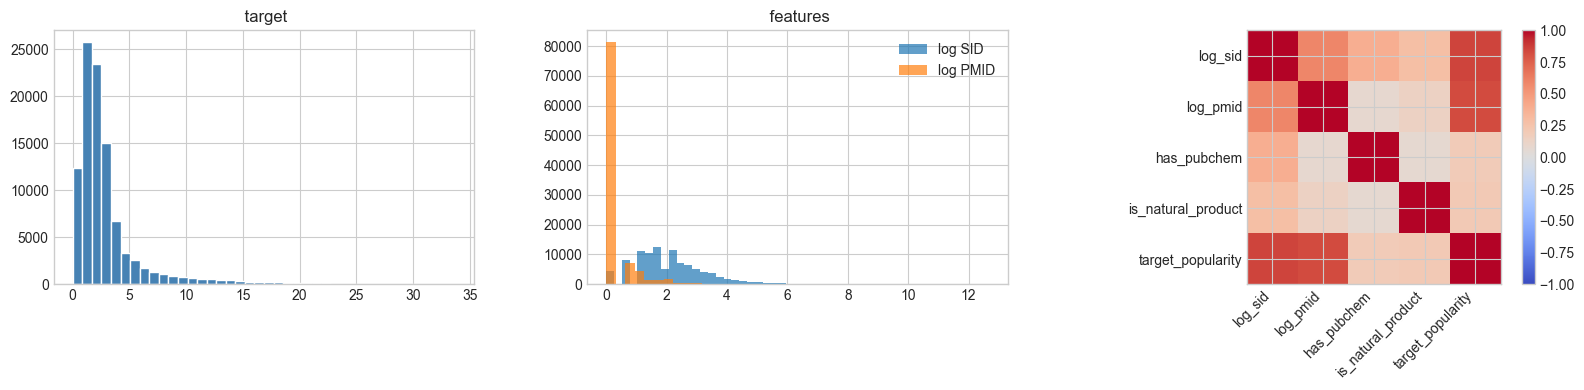

 target:
log_sid               0.847959
log_pmid              0.822018
is_natural_product    0.204864
has_pubchem           0.195056
Name: target_popularity, dtype: float64


In [3]:
# Descriptive statistics and visualizations
print(df.describe().T)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df[target_col], bins=40, color="steelblue", edgecolor="white")
axes[0].set(title=" target", xlabel="", ylabel="")
axes[1].hist(df["log_sid"], bins=40, alpha=.7, label="log SID")
axes[1].hist(df["log_pmid"], bins=40, alpha=.7, label="log PMID")
axes[1].set(title=" features"); axes[1].legend()
corr = df[feature_cols + [target_col]].corr()
im = axes[2].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
axes[2].set_yticks(range(len(corr)), corr.index); axes[2].set_title("")
fig.colorbar(im, ax=axes[2], fraction=.046)
plt.tight_layout(); plt.show()
print(" target:")
print(corr[target_col].drop(target_col).sort_values(ascending=False))

---
## Part 2: CLO1 — การวิเคราะห์ด้วยพีชคณิตเชิงเส้น

ใช้ PCA บน feature matrix ที่ผ่าน standardization และคำนวณ covariance matrix กับ eigendecomposition ด้วย NumPy


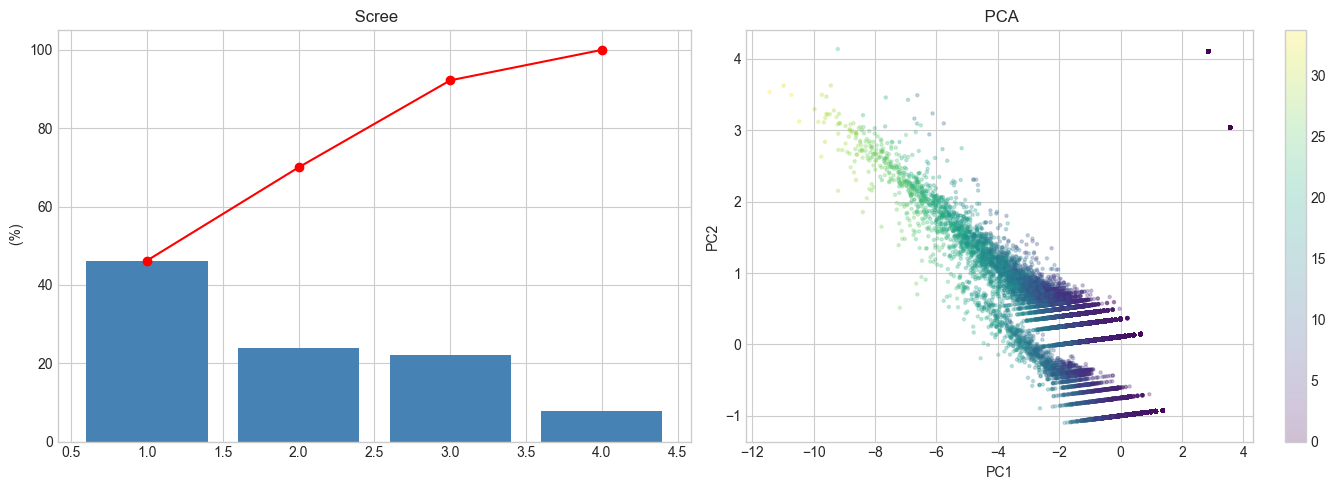

 (%): [46.23 23.79 22.21  7.77]
 PC1:
log_sid              -0.665551
log_pmid             -0.548639
has_pubchem          -0.373917
is_natural_product   -0.340915
dtype: float64


In [4]:
# PCA  covariance matrix
X = df[feature_cols].to_numpy(dtype=float)
y = df[target_col].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)
C = np.cov(X_scaled, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(C)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]; eigenvectors = eigenvectors[:, order]
explained = eigenvalues / eigenvalues.sum()
X_pca = X_scaled @ eigenvectors[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained)+1), explained*100, color="steelblue")
axes[0].plot(range(1, len(explained)+1), np.cumsum(explained)*100, "o-r")
axes[0].set(xlabel="", ylabel=" (%)", title=" Scree")
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=5, alpha=.25, cmap="viridis")
axes[1].set(xlabel="PC1", ylabel="PC2", title=" PCA")
fig.colorbar(sc, ax=axes[1], label="")
plt.tight_layout(); plt.show()
print(" (%):", np.round(explained*100, 2))
print(" PC1:")
print(pd.Series(eigenvectors[:, 0], index=feature_cols).sort_values(key=np.abs, ascending=False))

**ข้อค้นพบจาก CLO1:** PC1 สรุปทิศทางร่วมหลักของตัวแปรความนิยม และ PCA ช่วยลดมิติข้อมูลเพื่อมองเห็นโครงสร้างในสองมิติ


---
## Part 3: CLO2 — การเรียนรู้เชิงสถิติ

Target เป็นคะแนนต่อเนื่อง จึงเป็นปัญหา regression ใช้ polynomial regression เพื่อแสดง bias-variance trade-off


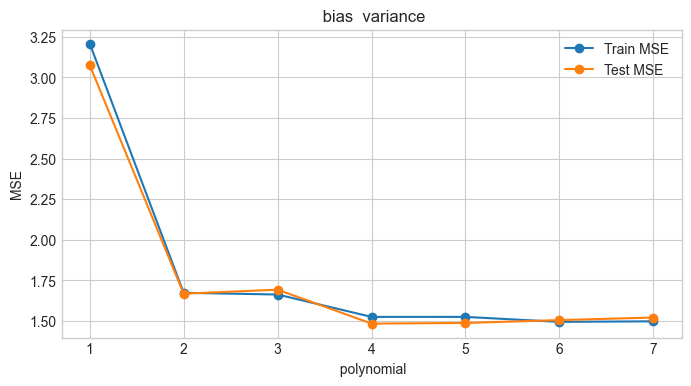

 test MSE : 4
log_sid               0.847959
log_pmid              0.822018
is_natural_product    0.204864
has_pubchem           0.195056
Name: target_popularity, dtype: float64


In [5]:
# Correlation  bias-variance U-curve
from sklearn.model_selection import train_test_split
X_one = df[["log_sid"]].to_numpy()
Xtr, Xte, ytr, yte = train_test_split(X_one, y, test_size=.2, random_state=42)
degrees = range(1, 8); train_mse, test_mse = [], []
for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(Xtr, ytr)
    train_mse.append(mean_squared_error(ytr, model.predict(Xtr)))
    test_mse.append(mean_squared_error(yte, model.predict(Xte)))
plt.figure(figsize=(8, 4)); plt.plot(degrees, train_mse, "o-", label="Train MSE"); plt.plot(degrees, test_mse, "o-", label="Test MSE")
plt.xlabel(" polynomial"); plt.ylabel("MSE"); plt.title(" bias  variance"); plt.legend(); plt.show()
print(" test MSE :", degrees[int(np.argmin(test_mse))])
print(df[feature_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False))

**ข้อค้นพบจาก CLO2:** `log_sid` และ `log_pmid` มีความสัมพันธ์กับ popularity สูงที่สุด และ degree ที่สูงเกินไปอาจทำให้เกิด overfitting


---
## Part 4: CLO3 — การสร้างแบบจำลอง

เปรียบเทียบ Simple Linear Regression ที่ใช้ `log_sid` กับ Ridge Regression ที่ใช้ทุก features


                   Model  Train MSE  Test MSE  Train R2  Test R2
Simple Linear Regression   3.208771  3.076290  0.717258 0.726204
    Ridge (all features)   1.324882  1.359901  0.883258 0.878966
Simple-model coefficient: 2.3900787394228455 intercept: -2.0344858680739093


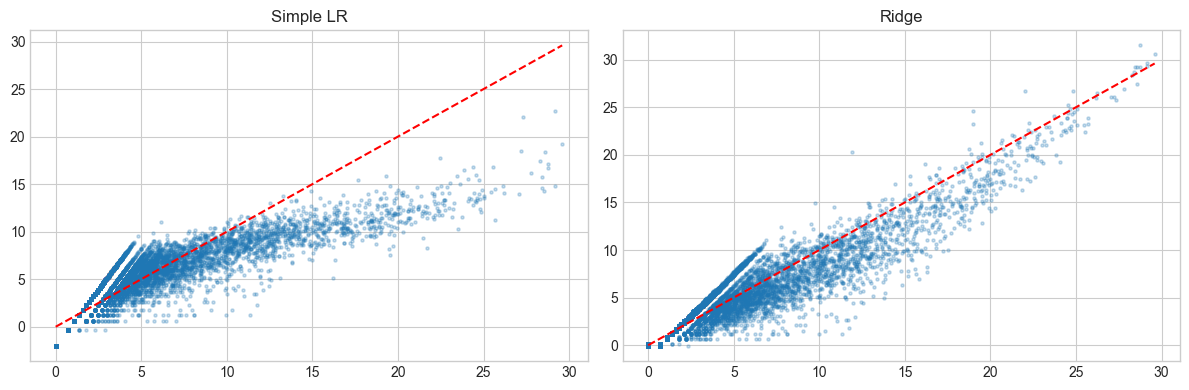

In [6]:
#  train/test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

model1 = LinearRegression().fit(X_train[:, [0]], y_train)
pred1_train = model1.predict(X_train[:, [0]]); pred1_test = model1.predict(X_test[:, [0]])
model2 = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X_train, y_train)
pred2_train = model2.predict(X_train); pred2_test = model2.predict(X_test)

def regression_report(name, actual_train, pred_train, actual_test, pred_test):
    return {"Model": name, "Train MSE": mean_squared_error(actual_train, pred_train),
            "Test MSE": mean_squared_error(actual_test, pred_test),
            "Train R2": r2_score(actual_train, pred_train), "Test R2": r2_score(actual_test, pred_test)}
comparison = pd.DataFrame([
    regression_report("Simple Linear Regression", y_train, pred1_train, y_test, pred1_test),
    regression_report("Ridge (all features)", y_train, pred2_train, y_test, pred2_test),
])
print(comparison.to_string(index=False))
print("Simple-model coefficient:", model1.coef_[0], "intercept:", model1.intercept_)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, pred, title in [(ax[0], pred1_test, "Simple LR"), (ax[1], pred2_test, "Ridge")]:
    a.scatter(y_test, pred, s=5, alpha=.25); lo, hi = y_test.min(), y_test.max(); a.plot([lo,hi],[lo,hi], "r--")
    a.set(xlabel="", ylabel="", title=title)
plt.tight_layout(); plt.show()

**สรุปการเปรียบเทียบโมเดล:** Ridge ใช้ข้อมูลหลายแหล่งและมี regularization จึงให้ผลดีกว่าโมเดลพื้นฐาน


---
## Part 5: CLO4 — การเลือกโมเดล

เปรียบเทียบโมเดล 3 แบบด้วย 5-fold cross-validation โดยใช้ MSE


                  Model  CV MSE mean  CV MSE std
   Ridge (all features)     1.332199    0.045875
           polynomial 2     1.673161    0.065760
Simple Linear (log SID)     3.183481    0.138594


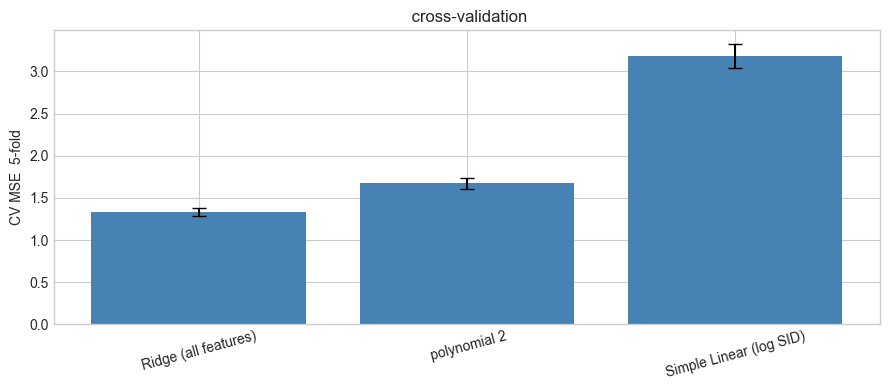

: Ridge (all features); CV MSE = 1.3322


In [7]:
# 5-Fold Cross-Validation
#  feature set 
models = {
    "Simple Linear (log SID)": (make_pipeline(StandardScaler(), LinearRegression()), X[:, [0]]),
    "Ridge (all features)": (make_pipeline(StandardScaler(), Ridge(alpha=1.0)), X),
    " polynomial 2": (make_pipeline(PolynomialFeatures(2), Ridge(alpha=1.0)), X[:, [0]]),
}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for name, (model, features) in models.items():
    scores = -cross_val_score(model, features, y, cv=kfold, scoring="neg_mean_squared_error", n_jobs=-1)
    cv_rows.append({"Model": name, "CV MSE mean": scores.mean(), "CV MSE std": scores.std()})
cv_results = pd.DataFrame(cv_rows).sort_values("CV MSE mean")
print(cv_results.to_string(index=False))
plt.figure(figsize=(9, 4)); plt.bar(cv_results["Model"], cv_results["CV MSE mean"], yerr=cv_results["CV MSE std"], capsize=5, color="steelblue")
plt.ylabel("CV MSE  5-fold"); plt.title(" cross-validation"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()
best_model_name = cv_results.iloc[0]["Model"]
print(f": {best_model_name}; CV MSE = {cv_results.iloc[0]['CV MSE mean']:.4f}")

**โมเดลที่ดีที่สุด:** Ridge (all features) มีค่าเฉลี่ย CV MSE ต่ำที่สุดประมาณ 1.3322


---
## Part 6: สรุปผลและเรื่องราวจากข้อมูล

- **CLO1:** PCA แสดงทิศทางความแปรปรวนหลักของข้อมูล
- **CLO2:** `log_sid` และ `log_pmid` มีความสัมพันธ์กับ popularity สูง
- **CLO3:** Ridge ทำได้ดีกว่า Simple Linear Regression
- **CLO4:** 5-fold cross-validation ช่วยเลือกโมเดลอย่างเป็นธรรม

**ข้อจำกัด:** target popularity เป็น prior จาก count data ไม่ใช่ค่าคุณภาพของสารโดยตรง และใช้ sample 100,000 แถวเพื่อให้รันได้บนคอมพิวเตอร์ทั่วไป

**งานต่อยอด:** วิเคราะห์ `pc_*` ทั้งชุดแบบ out-of-core และทดลอง ranking metrics

**กิตติกรรมประกาศ:** ขอขอบคุณผู้จัดทำชุดข้อมูลและ KaggleHub
